<a href="https://colab.research.google.com/github/shuyu-d/IDL_TPs/blob/master/tp6_idl_solution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TP 6 - SGD pour l'entraînement des MLPs

Dans ce TP, nous implémentons l'algorithme SGD pour entraîner un MLP construit avec Numpy.

Les données d'observation appartiennent au jeu de données Iris, déjà disponible via scikit-learn (`sklearn datasets`, voir "Préparation du jeu de données"). Plus d'information sur ce jeu de données : https://scikit-learn.org/1.4/auto_examples/datasets/plot_iris_dataset.html,   https://archive.ics.uci.edu/dataset/53/iris. 

In [18]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import time

### Préparation du jeu de données 
Ce jeu de données contient trois espèces différentes d’iris (Setosa, Versicolour et Virginica), caractérisées par la longueur et la largeur des sépales et des pétales. 
Les données sont stockées dans un tableau NumPy de dimension 150 x 4.

Les lignes correspondent aux observations (échantillons) et les colonnes représentent respectivement : longueur du sépale, largeur du sépale, longueur du pétale et largeur du pétale.

In [19]:
iris = load_iris()
X = iris.data          # shape: (150, 4)
y = iris.target        # shape: (150,) ; classes 0,1,2


n_samples, n_features = X.shape
n_classes = len(np.unique(y))

print("X shape:", X.shape)
print("Nombre de classes:", n_classes)

# Train / test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# Standardisation
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X shape: (150, 4)
Nombre de classes: 3


### Classification multiclasses  

On définit $X$ le vecteur aléatoire associé aux quatres charactéristiques dans le jeu de données Iris. Maintenant l'ensemble $\mathcal{D} = (x^{(i)}, y^{(i)})_{i=1}^n$ avec $x^{(i)}\in\mathbb{R}^4$ et $y^{(i)} \in \{0,1,2\}$. 


Encodage one-hot pour les labels des trois classes : 

In [20]:
# Encodage one-hot
def one_hot(y, num_classes):
    Y = np.zeros((len(y), num_classes))
    Y[np.arange(len(y)), y] = 1
    return Y

Y_train = one_hot(y_train, n_classes)
Y_test = one_hot(y_test, n_classes) 

#### Classification binaire (Setosa vs non-Setosa) avec les données de "Petal length"
 

In [21]:

n, p = X_train.shape

print('A few rows of Xtrain (shape %d x %d) : \n' %(n,p), pd.DataFrame(X_train).head() ) 
print('A few rows of y_train (shape %d x 1): \n'%y_train.shape[0], pd.DataFrame(Y_train).head() ) 

A few rows of Xtrain (shape 112 x 4) : 
           0         1         2         3
0  1.792138 -0.602380  1.315323  0.920954
1  2.145311 -0.602380  1.653204  1.051355
2 -0.444618 -1.507973 -0.036202 -0.252651
3  0.261726 -0.602380  0.132739  0.138551
4 -0.444618 -1.281575  0.132739  0.138551
A few rows of y_train (shape 112 x 1): 
      0    1    2
0  0.0  0.0  1.0
1  0.0  0.0  1.0
2  0.0  1.0  0.0
3  0.0  1.0  0.0
4  0.0  1.0  0.0


###  Construction et initialisation d'un MLP 

**Parametres du MLP** 

* Entrées : $p=4$ 
* 1 couche cachée : $\sigma_1=$ReLU
    * couche cachée 1: 10 neurones
    
* Sortie : 
    * $\sigma_2$=softmax 
    * $y=f_{\theta}(x) \in (0,1)^{K}$ où $K=3$.  
  
**Risque empirique** 

Pour un seul échantillon $(x, y)$, la fonction de perte du MLP, qui donnera la sorite $\hat{y}$ pour l'entrée $x$, est définie par l'entropie croisée (cross entropy) : 
    $L(\hat{y}, y) = - \sum_{k=1}^K y_k \log( \hat{y}_k ).$

On définit le risque empirique suivant comme l'objectif de l'entraînement : 
$$ R(\theta) = \frac{1}{2}\sum_{i=1}^n L(\hat{y}^{(i)}, y^{(i)} ).$$


In [22]:
# Parametres du MLP (2 couches cachées : sigma_1=ReLU, sigma_2=ReLU, sortie sigma_3=sigmoid)
#  - couche cachée 1: 10 neurones
#  - Sorite:          label one-hot de dimension 3 

# Fonctions utilitaires

def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    return (z > 0).astype(float)

def softmax(z):
    """
    z: vecteur de taille (n_classes,)
    """
    z_shift = z - np.max(z)  # stabilité numérique
    exp_z = np.exp(z_shift)
    return exp_z / np.sum(exp_z)

def cross_entropy_loss(y_true, y_pred):
    """
    y_true: vecteur one-hot (n_classes,)
    y_pred: probabilités softmax (n_classes,)
    """
    eps = 1e-12
    y_pred = np.clip(y_pred, eps, 1 - eps)
    return -np.sum(y_true * np.log(y_pred))

def accuracy(y_true_labels, y_pred_labels):
    return np.mean(y_true_labels == y_pred_labels)


# Architecture du MLP
#    Entrée (4) -> Cachée (H) -> Sortie (3)

input_dim = n_features      # 4
hidden_dim = 10             # nombre de neurones cachés
output_dim = n_classes      # 3

rng = np.random.default_rng(42)

# Initialisation des poids
W1 = rng.normal(0, 0.5, size=(hidden_dim, input_dim))   # (H, 4)
b1 = np.zeros(hidden_dim)                               # (H,)

W2 = rng.normal(0, 0.5, size=(output_dim, hidden_dim)) # (3, H)
b2 = np.zeros(output_dim)                               # (3,)

#### Question (a) : passe avant

A l'aide de l'Exercice 6.2 (i), compléter la fonction `passe_avant()` pour l'évaluation de la fonction de prédiction $f_{\theta}(\cdot)$ sur un ensemble de données $X$, étant donné le paramètre $\theta=(W^{(i)}, b^{(i)})_{i=1,2,3}$ du MLP. 



In [23]:
# Passe avant (forward pass) pour un seul échantillon (x,y)

def forward(x, W1, b1, W2, b2):
    """
    x : shape (4,)
    Retourne toutes les quantités utiles pour la rétropropagation
    """
    # Couche cachée
    z1 = W1 @ x + b1           # (H,)
    a1 = relu(z1)              # (H,)

    # Couche de sortie
    z2 = W2 @ a1 + b2          # (3,)
    y_hat = softmax(z2)        # (3,)

    cache = {
        "x": x,
        "z1": z1,
        "a1": a1,
        "z2": z2,
        "y_hat": y_hat
    }
    return y_hat, cache

# Fonctions pour la prédiction f_{\theta}(x) et pour l'évaluation: 

def predict(X, W1, b1, W2, b2):
    preds = []
    for x in X:
        y_hat, _ = forward(x, W1, b1, W2, b2)
        preds.append(np.argmax(y_hat))
    return np.array(preds)

def evaluate(X, y_labels, Y_onehot, W1, b1, W2, b2):
    total_loss = 0.0
    preds = []

    for x, y_true_vec in zip(X, Y_onehot):
        y_hat, _ = forward(x, W1, b1, W2, b2)
        total_loss += cross_entropy_loss(y_true_vec, y_hat)
        preds.append(np.argmax(y_hat))

    preds = np.array(preds)
    avg_loss = total_loss / len(X)
    acc = accuracy(y_labels, preds)
    return avg_loss, acc




#### Question (b) : passe arrière 
A l'aide des équations pour le calcul des dérivées partielles $\frac{\partial R}{\partial W^{(\ell)}_{ij}}$, compléter les lignes pour le passe arrière dans le bloc de l'algorithme GD suivant. 

In [24]:
# Backpropagation pour un seul échantillon 

def backward(y_true, cache, W2):
    """
    y_true : shape (3,) (one-hot)
    cache  : sorite, les pré-activations (z) et les activations (a) issu de forward
    W2     : utile pour rétropropager vers la couche cachée

    Retourne les gradients :
      dW1, db1, dW2, db2
    """
    x = cache["x"]         # (4,)
    z1 = cache["z1"]       # (H,)
    a1 = cache["a1"]       # (H,)
    y_hat = cache["y_hat"] # (3,)

    # --------------------------------------------------------
    # Sortie softmax + cross-entropy :
    # delta2 = y_hat - y_true
    # --------------------------------------------------------
    delta2 = y_hat - y_true            # (3,)

    dW2 = np.outer(delta2, a1)         # (3, H)
    db2 = delta2                       # (3,)

    # --------------------------------------------------------
    # Couche cachée :
    # delta1 = (W2^T delta2) ⊙ ReLU'(z1)
    # --------------------------------------------------------
    delta1 = (W2.T @ delta2) * relu_derivative(z1)   # (H,)

    dW1 = np.outer(delta1, x)          # (H, 4)
    db1 = delta1                       # (H,)

    return dW1, db1, dW2, db2



### Entraînement avec SGD 

In [26]:
# 8) Entraînement avec SGD
# ============================================================

learning_rate = 0.01
n_epochs = 300

train_losses = []
train_accuracies = []
test_losses = []
test_accuracies = []
times_epo = []
t1 = time.time()
for epoch in range(n_epochs):
    # Mélange des données à chaque époque
    indices = np.arange(len(X_train))
    np.random.shuffle(indices)

    X_train_shuffled = X_train[indices]
    Y_train_shuffled = Y_train[indices]

    # --------------------------------------------------------
    # SGD : une mise à jour par exemple
    # --------------------------------------------------------
    for x, y_true in zip(X_train_shuffled, Y_train_shuffled):
        # Forward
        y_hat, cache = forward(x, W1, b1, W2, b2)

        # Backward
        dW1, db1, dW2, db2 = backward(y_true, cache, W2)

        # Mise à jour SGD
        W1 -= learning_rate * dW1
        b1 -= learning_rate * db1
        W2 -= learning_rate * dW2
        b2 -= learning_rate * db2

    times_epo.append( time.time()-t1 )
    # Évaluation à la fin de l'époque
    train_loss, train_acc = evaluate(X_train, y_train, Y_train, W1, b1, W2, b2)
    test_loss, test_acc = evaluate(X_test, y_test, Y_test, W1, b1, W2, b2)

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    test_losses.append(test_loss)
    test_accuracies.append(test_acc)

    if (epoch + 1) % 20 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:3d}/{n_epochs} | "
              f"Train loss: {train_loss:.4f} | Train acc: {train_acc:.4f} | "
              f"Test loss: {test_loss:.4f} | Test acc: {test_acc:.4f}")

Epoch   1/300 | Train loss: 0.7667 | Train acc: 0.7411 | Test loss: 0.7930 | Test acc: 0.7105
Epoch  20/300 | Train loss: 0.0915 | Train acc: 0.9732 | Test loss: 0.1590 | Test acc: 0.9211
Epoch  40/300 | Train loss: 0.0605 | Train acc: 0.9732 | Test loss: 0.1281 | Test acc: 0.9211
Epoch  60/300 | Train loss: 0.0504 | Train acc: 0.9821 | Test loss: 0.1214 | Test acc: 0.9211
Epoch  80/300 | Train loss: 0.0480 | Train acc: 0.9732 | Test loss: 0.1389 | Test acc: 0.9474
Epoch 100/300 | Train loss: 0.0445 | Train acc: 0.9821 | Test loss: 0.1431 | Test acc: 0.9474
Epoch 120/300 | Train loss: 0.0415 | Train acc: 0.9821 | Test loss: 0.1242 | Test acc: 0.9474
Epoch 140/300 | Train loss: 0.0392 | Train acc: 0.9821 | Test loss: 0.1407 | Test acc: 0.9474
Epoch 160/300 | Train loss: 0.0387 | Train acc: 0.9821 | Test loss: 0.1388 | Test acc: 0.9474
Epoch 180/300 | Train loss: 0.0385 | Train acc: 0.9821 | Test loss: 0.1450 | Test acc: 0.9474
Epoch 200/300 | Train loss: 0.0394 | Train acc: 0.9732 | Tes

#### Résultats 


=== Accuracy ===
Accuracy train : 0.9821428571428571
Accuracy test  : 0.9210526315789473

 Prédictions sur quelques données test :
Vrai = 0, Prédit = 0
Vrai = 1, Prédit = 1
Vrai = 1, Prédit = 1
Vrai = 1, Prédit = 1
Vrai = 0, Prédit = 0
Vrai = 1, Prédit = 1
Vrai = 2, Prédit = 2
Vrai = 2, Prédit = 2
Vrai = 2, Prédit = 2
Vrai = 2, Prédit = 2


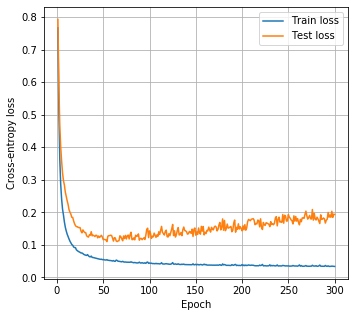

In [29]:
# Résultats finaux

y_pred_test = predict(X_test, W1, b1, W2, b2)

print("\n=== Accuracy ===")
print("Accuracy train :", train_accuracies[-1])
print("Accuracy test  :", test_accuracies[-1])

print("\n Prédictions sur quelques données test :")
for i in range(min(10, len(X_test))):
    print(f"Vrai = {y_test[i]}, Prédit = {y_pred_test[i]}")


# ----
# Courbes d'apprentissage
import matplotlib.pyplot as plt
epochs = np.arange(1, n_epochs + 1)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, label="Train loss")
# plt.plot(times_epo, train_losses, label="Train loss")
plt.plot(epochs, test_losses, label="Test loss")
# plt.plot(times_epo, test_losses, label="Test loss")
plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss")
plt.legend()
plt.grid(True)